In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# linear regression

In [35]:
x_data = np.array([1,2,3,4,5])
y_data = x_data*2

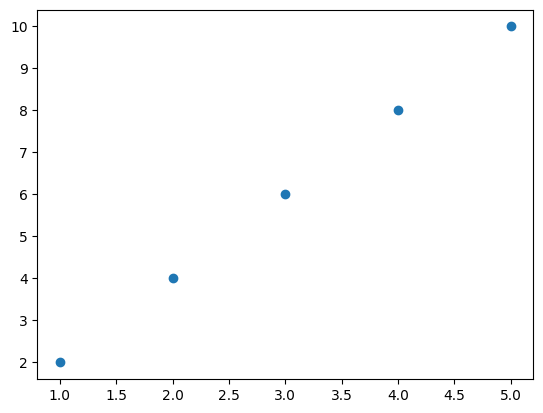

In [36]:
plt.scatter(x_data, y_data)
plt.show()

In [37]:
def forward(x, w, b=0):
    y_hat = x*w + b
    return y_hat





In [38]:
def loss(y_hat, y):
    return (y_hat - y) ** 2

In [39]:
all_w = []
all_loss = []

for w in np.arange(0,4, 0.1):
    l_sum =0
    for i in range(len(x_data)):
        y_hat = forward(x_data[i], w)
        l = loss(y_hat, y_data[i])

        l_sum +=l
    all_w.append(w)
    all_loss.append(l/ len(y_data))


# displaying the graph how it works

<StemContainer object of 3 artists>

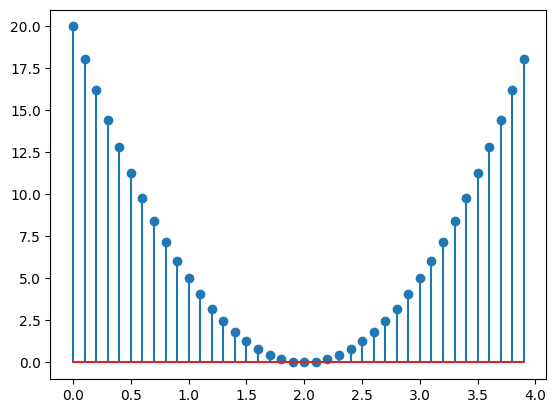

In [40]:
plt.stem(all_w, all_loss)

# now using pytorch

In [69]:
x_torch = torch.FloatTensor(x_data).reshape(-1,1)
y_torch = torch.FloatTensor(y_data).reshape(-1,1)

In [70]:
x_torch

tensor([[1.],
        [2.],
        [3.],
        [4.],
        [5.]])

In [71]:
y_torch

tensor([[ 2.],
        [ 4.],
        [ 6.],
        [ 8.],
        [10.]])

In [68]:
w = torch.randn(1, requires_grad = True)
b = torch.randn(1, requires_grad = True)

In [27]:
l_lr = 0.01

In [72]:
all_w = []
all_loss = []
for i in range(1000):
    y_hat = x_torch*w+b
    loss = torch.sum(torch.pow(y_torch - y_hat, 2)/len(y_torch))
    loss.backward()
    with torch.no_grad():
        w -=l_lr * w.grad
        b -= l_lr* b.grad
        
    w.grad.zero_()
    b.grad.zero_()
    all_loss.append(loss.item())
    all_w.append(w.item())
    

In [73]:
y_pred = x_torch*w+b

In [74]:
y_pred

tensor([[2.0512],
        [4.0316],
        [6.0120],
        [7.9924],
        [9.9727]], grad_fn=<AddBackward0>)

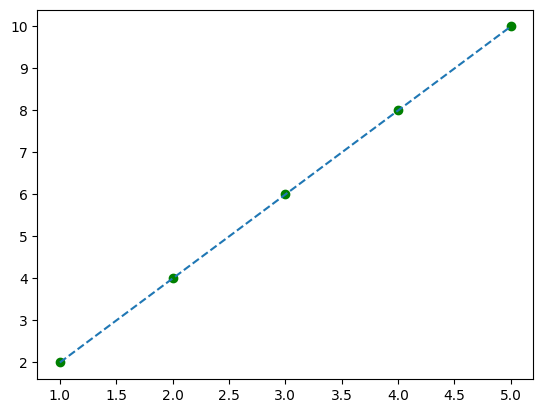

In [75]:
plt.plot(x_torch, y_torch, 'go')
plt.plot(x_torch, y_torch.detach().numpy(), '--')

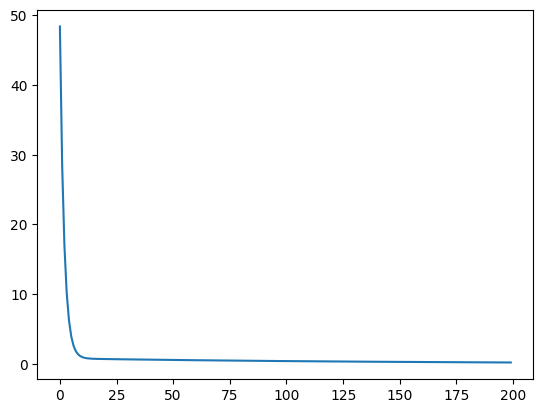

In [76]:
plt.plot(np.arange(0,200,1),  all_loss[:200])

In [77]:
all_loss

[48.40256881713867,
 28.534137725830078,
 16.953594207763672,
 10.202827453613281,
 6.266635417938232,
 3.970651149749756,
 2.6305124759674072,
 1.8474094867706299,
 1.388932228088379,
 1.1196465492248535,
 0.9606257081031799,
 0.8658754825592041,
 0.8085938096046448,
 0.7731608152389526,
 0.7504743337631226,
 0.7352288365364075,
 0.7243332862854004,
 0.7159872055053711,
 0.7091392874717712,
 0.7031781077384949,
 0.6977472305297852,
 0.6926385760307312,
 0.6877306699752808,
 0.6829527616500854,
 0.6782634854316711,
 0.6736389994621277,
 0.6690646409988403,
 0.6645325422286987,
 0.6600375175476074,
 0.6555766463279724,
 0.6511482000350952,
 0.646750807762146,
 0.6423838138580322,
 0.6380466818809509,
 0.6337394118309021,
 0.629460871219635,
 0.6252119541168213,
 0.6209911704063416,
 0.616798996925354,
 0.6126353740692139,
 0.6084996461868286,
 0.6043921709060669,
 0.6003122925758362,
 0.5962598323822021,
 0.5922346711158752,
 0.5882366895675659,
 0.584265947341919,
 0.5803217887878418,


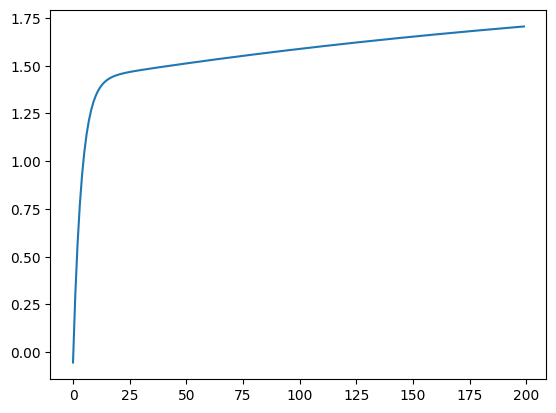

In [78]:
plt.plot(np.arange(0,200,1), all_w[:200])

In [79]:
w,b

(tensor([1.9804], requires_grad=True), tensor([0.0708], requires_grad=True))

In [80]:
x_test = torch.Tensor([3.5])

In [81]:
x_test *w +b

tensor([7.0022], grad_fn=<AddBackward0>)

# now we build using torch.nn.Module

In [15]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.linear = torch.nn.Linear(1,1)

    def forward(self, x):
        return self.linear(x)


In [26]:
x = np.random.rand(50)
x = x*10
y = x*3-4
y += np.random.randn(50)
x,y

(array([1.21890597, 3.11721472, 6.36577022, 4.71385041, 5.69641555,
        8.89790382, 0.1128974 , 3.62059846, 9.40261761, 9.27734185,
        3.18408018, 7.48592555, 1.5174357 , 2.60521578, 4.61989843,
        1.29674891, 4.92300007, 2.96190315, 6.78860063, 1.04489738,
        0.11306467, 8.07147288, 3.32171504, 3.38489757, 1.41937782,
        3.00177882, 5.36829604, 4.88528312, 6.37036894, 5.14694828,
        6.04179037, 7.39563549, 2.18137517, 1.93867806, 4.2264458 ,
        2.20692828, 7.71086515, 9.85621725, 3.84534627, 2.31825475,
        5.16166159, 8.50278519, 9.10960344, 4.33436965, 4.58962595,
        6.7883372 , 1.09467962, 7.80605188, 9.25892907, 8.04851206]),
 array([ 0.28610901,  3.68441057, 15.45981029,  8.62001606, 14.52393041,
        23.26536089, -1.19076212,  8.03393546, 23.84093945, 25.98972137,
         4.75796498, 19.74493196,  0.82710535,  3.49811479, 10.3197716 ,
        -1.21626492, 11.12254277,  7.72069098, 15.55284925,  0.09219014,
        -3.51498609, 19.40

In [27]:
x_torch = torch.FloatTensor(x).reshape(-1,1)
y_torch = torch.FloatTensor(y).reshape(-1,1)

In [28]:
model = LinearModel()
critia = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)


In [29]:
all_loss = []
for epoch in range(1000):
    y_hat = model(x_torch)
    loss = critia(y_hat, y_torch)
    loss.backward()
    all_loss.append(loss.item())
    optimizer.step()
    optimizer.zero_grad()
    

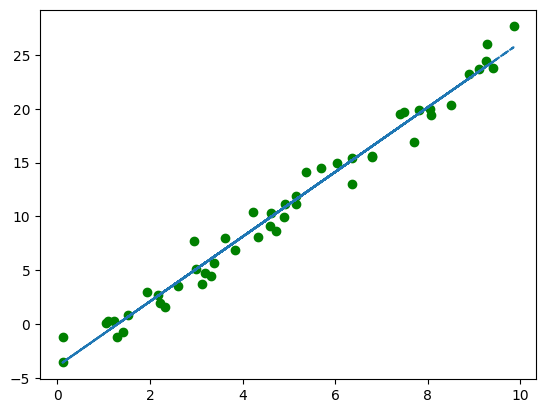

In [30]:
y_pred = model.forward(x_torch)
plt.plot(x_torch, y_torch, 'go')
plt.plot(x_torch, y_pred.detach().numpy(), '--')

In [31]:
for name, param in model.named_parameters():
    print(name, param)

linear.weight Parameter containing:
tensor([[3.0063]], requires_grad=True)
linear.bias Parameter containing:
tensor([-3.9096], requires_grad=True)


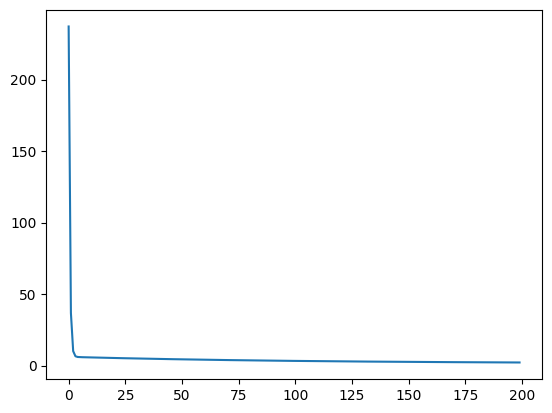

In [33]:
plt.plot(np.arange(0,200,1), all_loss[:200])